In [1]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import cv2
from utils.data_loader import preview_augmentation, load_single_image, EMOTION_MAP

# Thiết lập kích thước hiển thị mặc định
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Chọn ngẫu nhiên một vài mẫu từ tập dữ liệu
Lấy thử một số ảnh thuộc các biểu cảm khác nhau từ tập `train` để làm mẫu trực quan.

In [2]:
DATA_DIR = 'data/DATASET/train'
sample_images = []

# Lấy 1 ảnh từ 3 class đầu tiên để làm mẫu
for class_folder in sorted(os.listdir(DATA_DIR))[:3]:
    class_path = os.path.join(DATA_DIR, class_folder)
    if os.path.isdir(class_path):
        img_files = os.listdir(class_path)
        if img_files:
            sample_images.append({
                'path': os.path.join(class_path, img_files[0]),
                'label': EMOTION_MAP[int(class_folder)]
            })

print(f"Đã chọn {len(sample_images)} mẫu để demo.")

Đã chọn 3 mẫu để demo.


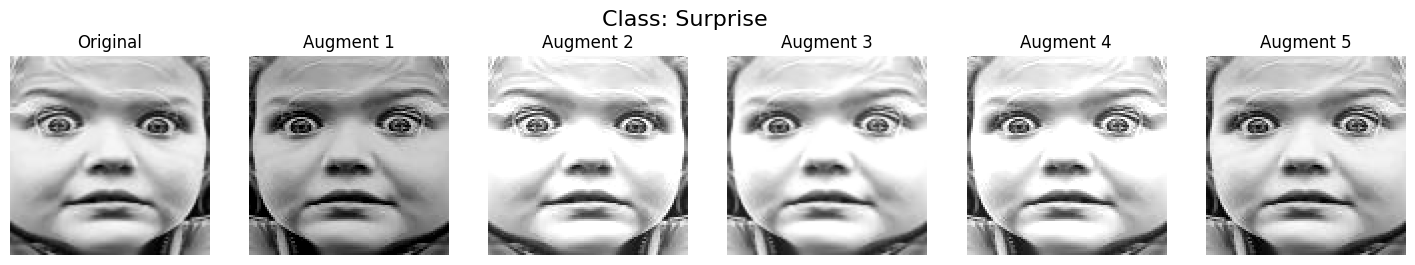

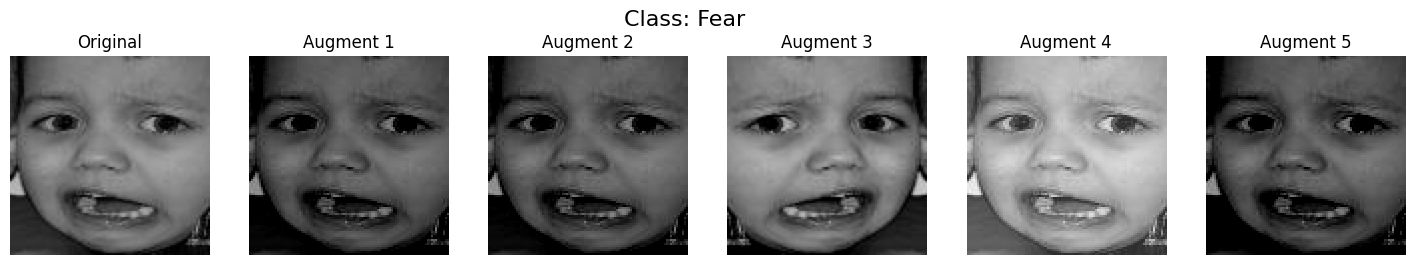

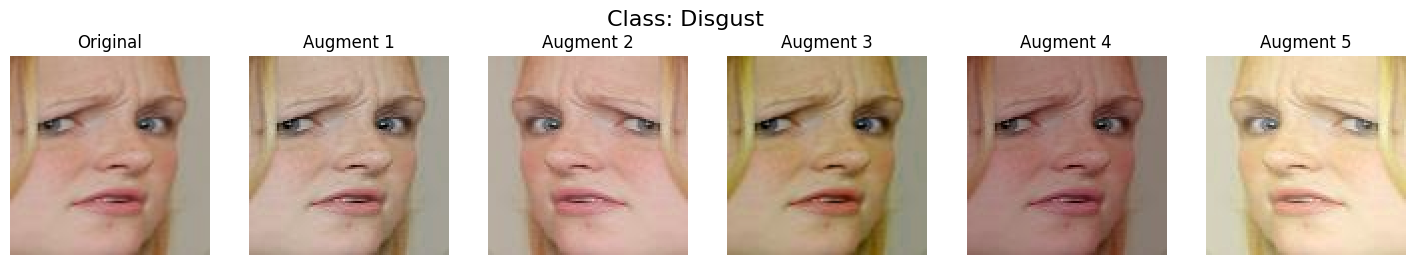

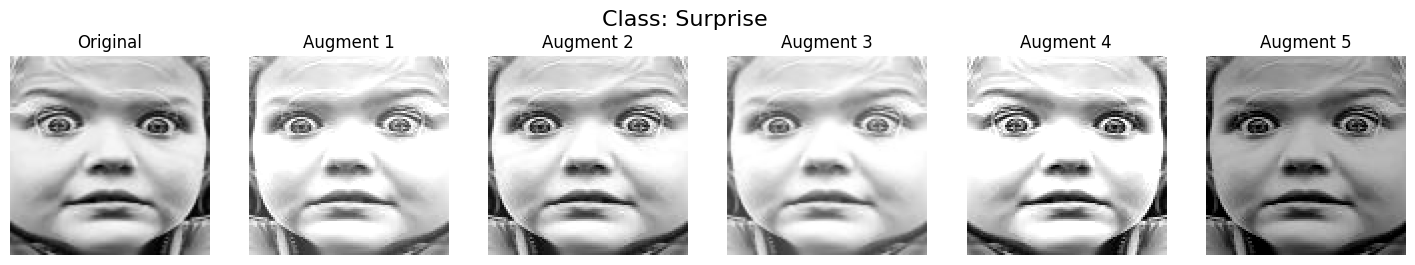

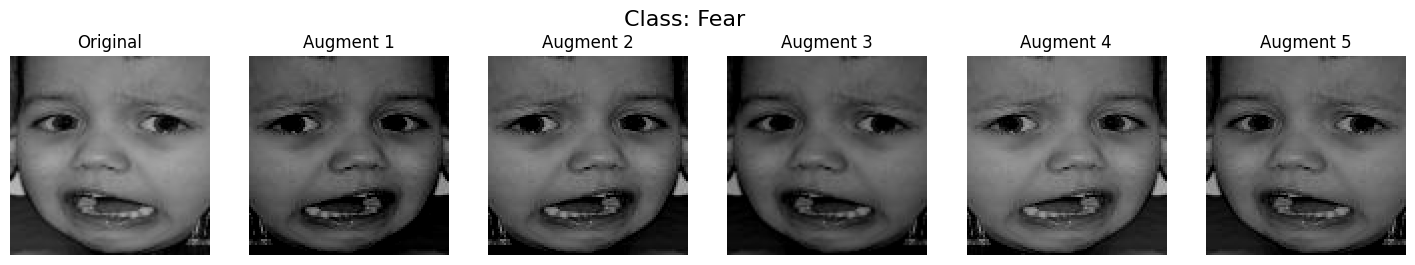

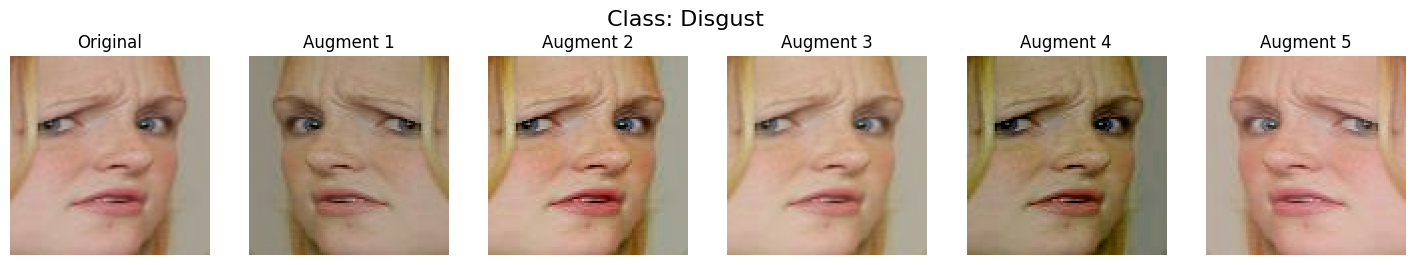

In [4]:
%matplotlib inline
for sample in sample_images:
    img_path = sample['path']
    label = sample['label']
    
    # Lấy ảnh gốc và các ảnh đã augment
    original, augmented_imgs = preview_augmentation(img_path, img_size=(100, 100), n_augments=5)
    
    # Vẽ hình
    fig, axes = plt.subplots(1, 6, figsize=(18, 3))
    fig.suptitle(f"Class: {label}", fontsize=16)
    
    # Ảnh gốc
    axes[0].imshow(original)
    axes[0].set_title("Original")
    axes[0].axis('off')
    
    # Ảnh augment
    for i, aug_img in enumerate(augmented_imgs):
        axes[i+1].imshow(aug_img)
        axes[i+1].set_title(f"Augment {i+1}")
        axes[i+1].axis('off')
        
    plt.show()

## 3. Quá trình Chuẩn hóa (Normalization) đầu vào cho Model
Model sẽ không nhận ảnh với giá trị pixel từ 0-255 thông thường, mà nhận dữ liệu đã được chuẩn hóa theo mean/std của tập dữ liệu RAF-DB. Hãy xem sự khác biệt giữa ảnh gốc và tensor đầu vào.

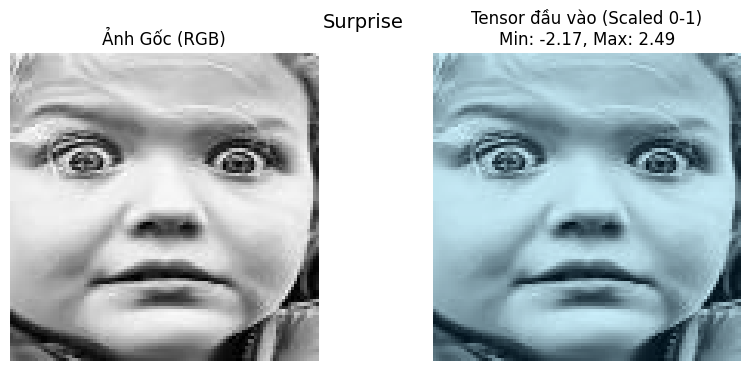

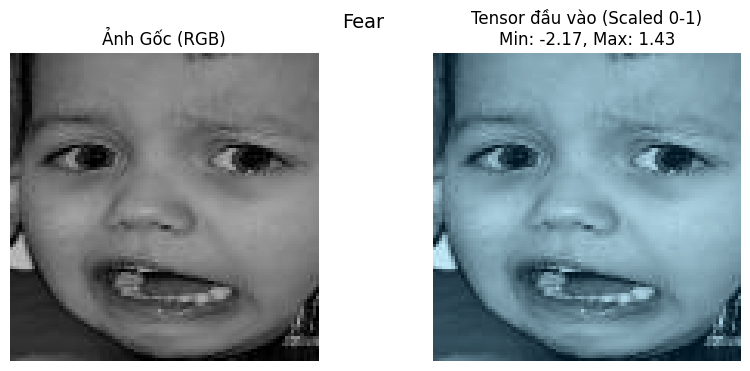

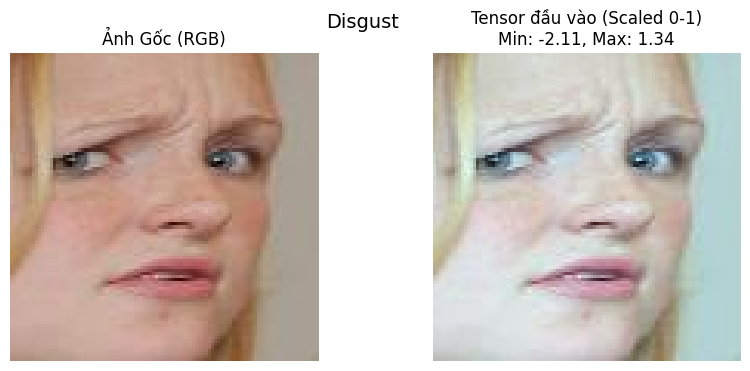

In [5]:
for sample in sample_images:
    img_path = sample['path']
    label = sample['label']
    
    # load_single_image trả về tensor [1, H, W, 3] và ảnh gốc BGR
    model_input, original_bgr = load_single_image(img_path, img_size=(100, 100))
    
    # Chuyển BGR -> RGB để hiển thị ảnh gốc
    original_rgb = cv2.cvtColor(original_bgr, cv2.COLOR_BGR2RGB)
    
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    fig.suptitle(f"{label}", fontsize=14)
    
    axes[0].imshow(original_rgb)
    axes[0].set_title("Ảnh Gốc (RGB)")
    axes[0].axis('off')
    
    # Visualize tensor đầu vào (chỉ hiển thị phân phối giá trị)
    tensor_vis = model_input[0]  # Lấy phần tử đầu tiên trong batch
    
    # Scale lại về 0-1 để hiển thị dạng ảnh (chỉ dùng cho trực quan hóa)
    tensor_min = tensor_vis.min()
    tensor_max = tensor_vis.max()
    tensor_scaled = (tensor_vis - tensor_min) / (tensor_max - tensor_min)
    
    axes[1].imshow(tensor_scaled)
    axes[1].set_title(f"Tensor đầu vào (Scaled 0-1)\nMin: {tensor_min:.2f}, Max: {tensor_max:.2f}")
    axes[1].axis('off')
    
    plt.show()